In [1]:
import numpy as np

X1_train = np.load("../models/X1_train.npy")
X1_test  = np.load("../models/X1_test.npy")
y1_train = np.load("../models/y1_train.npy")
y1_test  = np.load("../models/y1_test.npy")

print("Train shape:", X1_train.shape, y1_train.shape)
print("Test shape:", X1_test.shape, y1_test.shape)


Train shape: (59793, 48, 11) (59793, 6, 4)
Test shape: (14949, 48, 11) (14949, 6, 4)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Attention, Concatenate, Reshape

# timesteps = X1_train.shape[1]
# features = X1_train.shape[2]

# inputs = Input(shape=(timesteps, features))

# # First LSTM layer
# x = LSTM(128, return_sequences=True)(inputs)
# x = Dropout(0.3)(x)

# # GRU layer to capture different temporal patterns
# x = GRU(64, return_sequences=True)(x)
# x = Dropout(0.3)(x)

# # Attention mechanism
# attention = Attention()([x, x])
# x = Concatenate()([x, attention])

# # Final LSTM layer
# x = LSTM(64)(x)
# x = Dropout(0.3)(x)

# # Output layer
# output = Dense(6 * 4)(x)
# output = Reshape((6, 4))(output)

# model1 = Model(inputs, output)

# model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model1.summary()

#Baseline LSTM model (commented out for now) similar performance to the improved model, so we can focus on the new architecture

model1 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X1_train.shape[1], X1_train.shape[2])),
    Dropout(0.2),
    
    LSTM(32),
    Dropout(0.2),
    
    Dense(6 * 4),  # 6 future steps × 4 parameters
])

# Reshape output to (forecast_horizon, features)
model1.add(tf.keras.layers.Reshape((6, 4)))

model1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model1.summary()



d:\Aditya\Projects\SDP\AquaCulture\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 4)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,664 (127.59 KB)

 Trainable params: 32,664 (127.59 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# base model training with early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model1.fit(
    X1_train, y1_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

# training for improved model with early stopping

# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=7,
#     restore_best_weights=True
# )

# history = model1.fit(
#     X1_train, y1_train,
#     validation_split=0.2,
#     epochs=60,
#     batch_size=128,
#     callbacks=[early_stop]
# )


Epoch 1/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 0.0242 - mae: 0.1156 - val_loss: 0.0146 - val_mae: 0.0960
Epoch 2/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0129 - mae: 0.0870 - val_loss: 0.0140 - val_mae: 0.0947
Epoch 3/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0115 - mae: 0.0812 - val_loss: 0.0139 - val_mae: 0.0943
Epoch 4/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0108 - mae: 0.0779 - val_loss: 0.0140 - val_mae: 0.0943
Epoch 5/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0104 - mae: 0.0759 - val_loss: 0.0139 - val_mae: 0.0942
Epoch 6/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0101 - mae: 0.0745 - val_loss: 0.0138 - val_mae: 0.0936
Epoch 7/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0099 - mae: 0.0735 - val_loss: 0.0136 - val_mae: 0.0929
Epoch 8/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0097 - mae: 0.0727 - val_loss: 0.0133 - val_mae: 0.0917
Epoch 9/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 

In [5]:
import json

with open("../models/feature_columns.json", "r") as f:
    feature_columns = json.load(f)

print(feature_columns)

target_indices = [
    feature_columns.index("do"),
    feature_columns.index("temperature"),
    feature_columns.index("ph"),
    feature_columns.index("turbidity")
]



['nitrate', 'ph', 'ammonia', 'temperature', 'do', 'turbidity', 'manganese', 'hour_sin', 'hour_cos', 'ammonia_ph', 'ammonia_temp']


In [6]:
test_loss, test_mae = model1.evaluate(X1_test, y1_test)
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)
y1_pred = model1.predict(X1_test)
print("Predicted shape:", y1_pred.shape)

468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0124 - mae: 0.0884
Test Loss (MSE): 0.012432912364602089
Test MAE: 0.08836135268211365
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Predicted shape: (14949, 6, 4)


In [7]:
sample_index = 0

pred = y1_pred[sample_index]
true = y1_test[sample_index]

print("Predicted (scaled):")
print(pred)

print("\nActual (scaled):")
print(true)

Predicted (scaled):
[[0.6679076  0.66074854 0.42932004 0.43743464]
 [0.6320087  0.65287346 0.42794454 0.35422346]
 [0.5568681  0.6555591  0.50413793 0.36448354]
 [0.5573144  0.6647979  0.5010814  0.3647017 ]
 [0.5624933  0.66700375 0.49684712 0.36179   ]
 [0.5677715  0.66444737 0.4885993  0.35901678]]

Actual (scaled):
[[0.7596841  0.7030635  0.4495016  0.43035117]
 [0.7837728  0.59835345 0.57125384 0.29907888]
 [0.75830394 0.6587074  0.55823386 0.3695383 ]
 [0.690758   0.64540994 0.6169695  0.4497669 ]
 [0.5979764  0.65115184 0.5295531  0.49557662]
 [0.5331886  0.5724362  0.5103446  0.42267594]]


In [8]:
model1.save("../models/model1_multivariate_lstm.keras")

In [9]:
import numpy as np

params = ["DO", "Temperature", "pH", "Turbidity"]

mae_per_param = np.mean(np.abs(y1_test - y1_pred), axis=(0,1))

for p, v in zip(params, mae_per_param):
    print(p, "MAE:", v)


DO MAE: 0.0963653
Temperature MAE: 0.07068198
pH MAE: 0.1100453
Turbidity MAE: 0.07635238


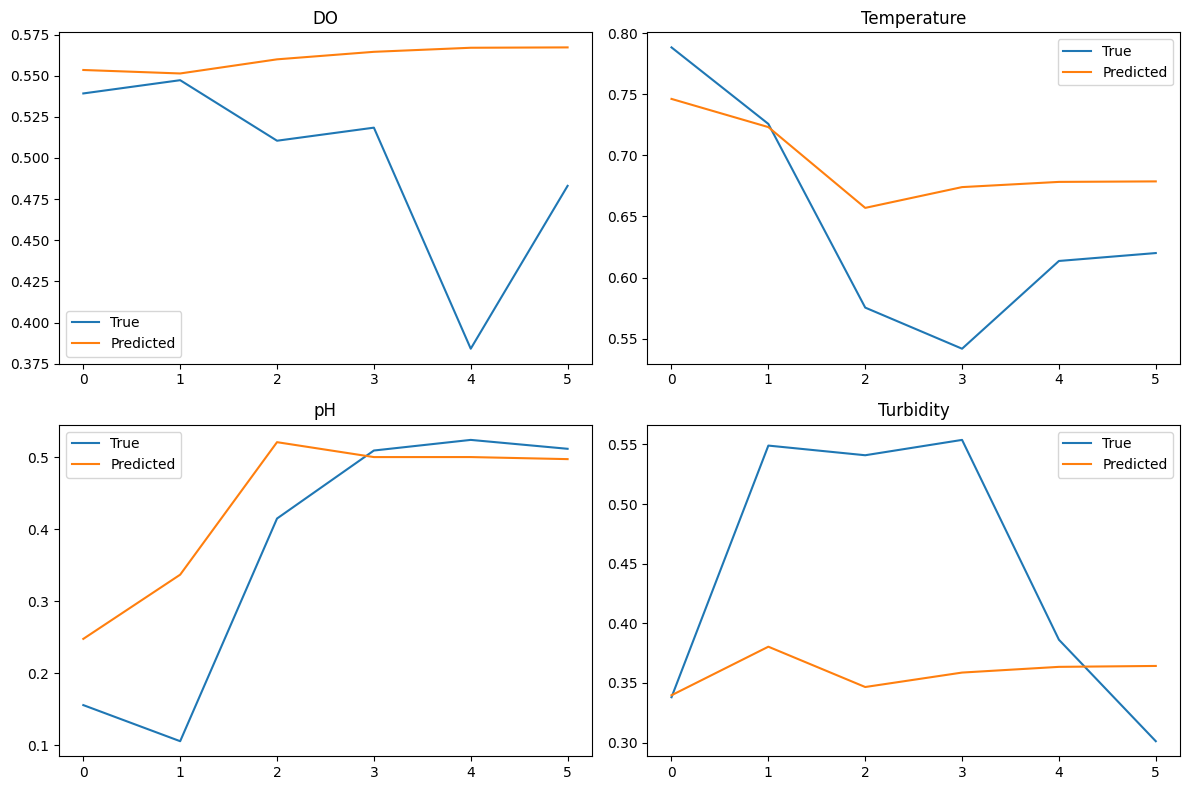

In [10]:
import matplotlib.pyplot as plt
model1 = tf.keras.models.load_model("../models/model1_multivariate_lstm.keras")

# Pick one test sample
sample = 10  

true_values = y1_test[sample]
pred_values = y1_pred[sample]

params = ["DO", "Temperature", "pH", "Turbidity"]

plt.figure(figsize=(12, 8))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(true_values[:, i], label="True")
    plt.plot(pred_values[:, i], label="Predicted")
    plt.title(params[i])
    plt.legend()

plt.tight_layout()
plt.show()


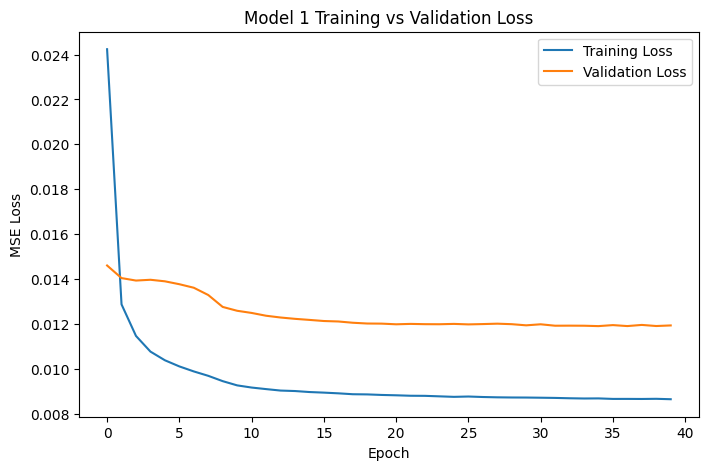

In [11]:
# Training and Validation Loss Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model 1 Training vs Validation Loss')
plt.legend()
plt.show()


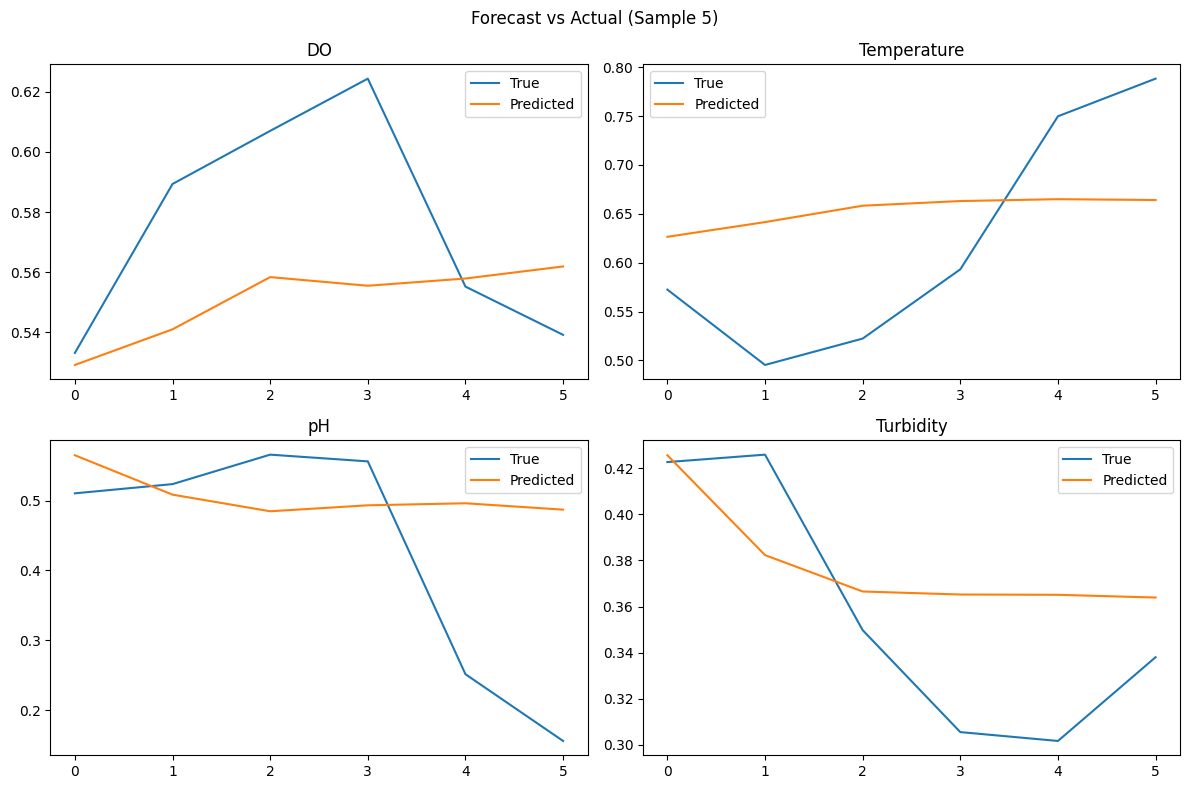

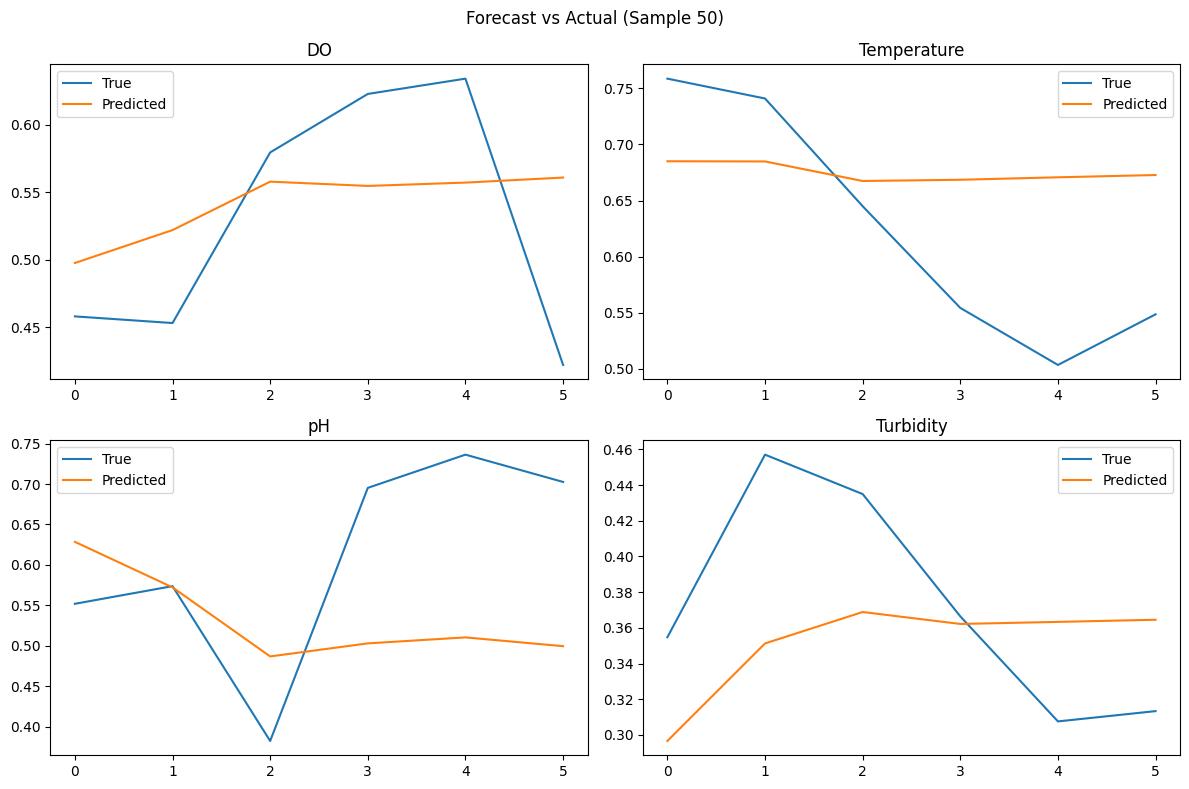

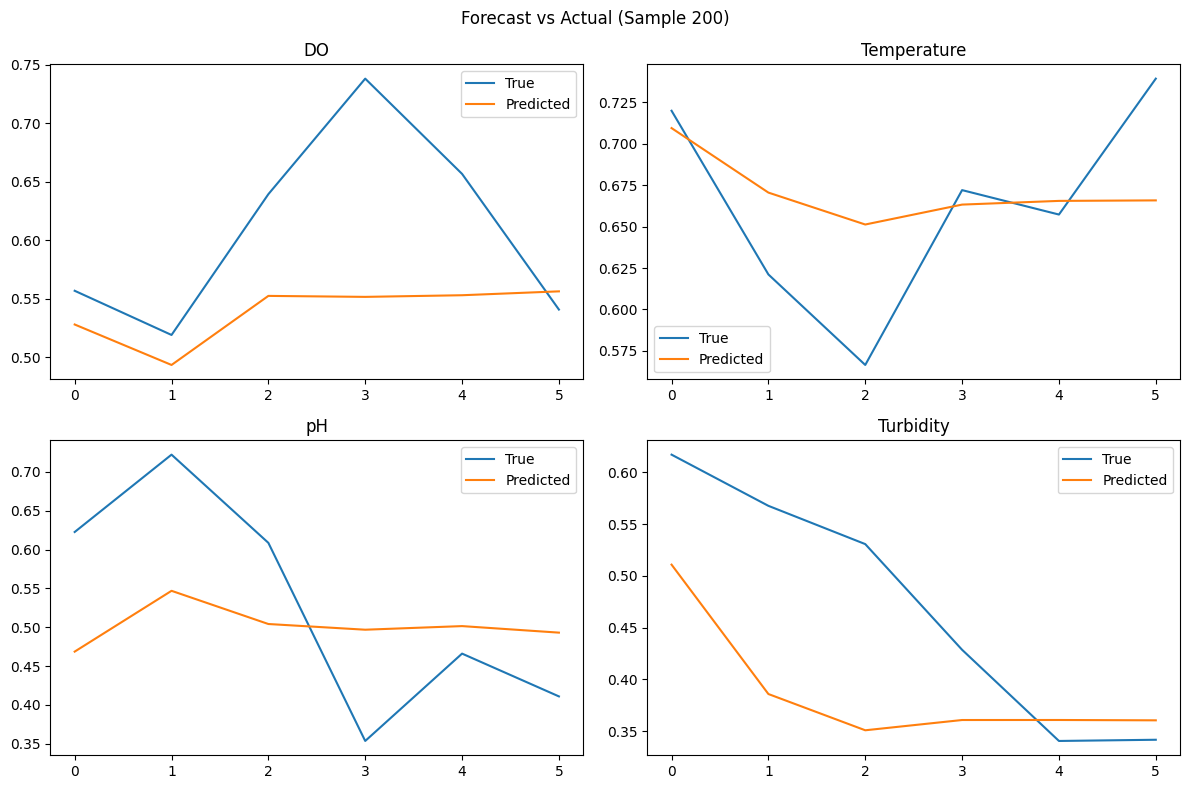

In [12]:
# Multi-Step Forecast Plot
params = ["DO", "Temperature", "pH", "Turbidity"]

samples_to_plot = [5, 50, 200]

for sample in samples_to_plot:
    plt.figure(figsize=(12,8))
    true_values = y1_test[sample]
    pred_values = y1_pred[sample]

    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.plot(true_values[:,i], label='True')
        plt.plot(pred_values[:,i], label='Predicted')
        plt.title(params[i])
        plt.legend()

    plt.suptitle(f"Forecast vs Actual (Sample {sample})")
    plt.tight_layout()
    plt.show()


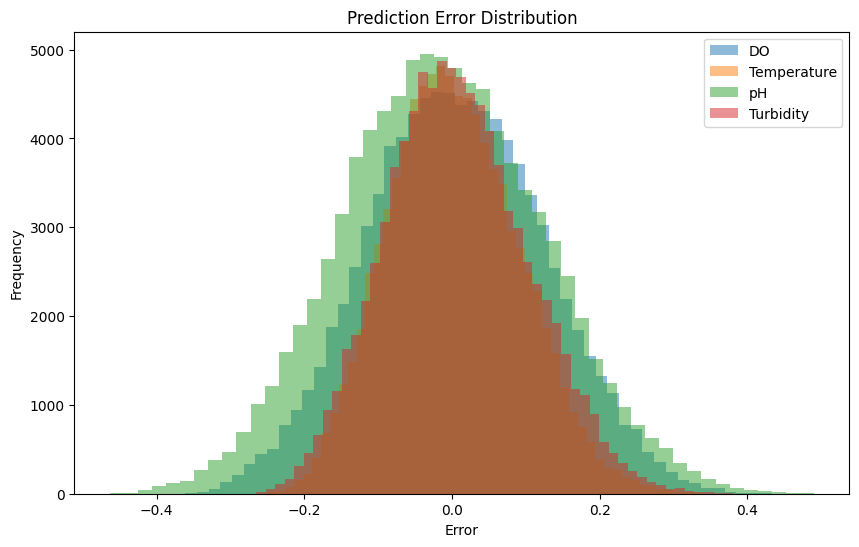

In [13]:
# Error Distribution Histogram
import numpy as np

errors = y1_test - y1_pred
errors_flat = errors.reshape(-1, errors.shape[-1])

plt.figure(figsize=(10,6))
for i, param in enumerate(params):
    plt.hist(errors_flat[:, i], bins=50, alpha=0.5, label=param)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


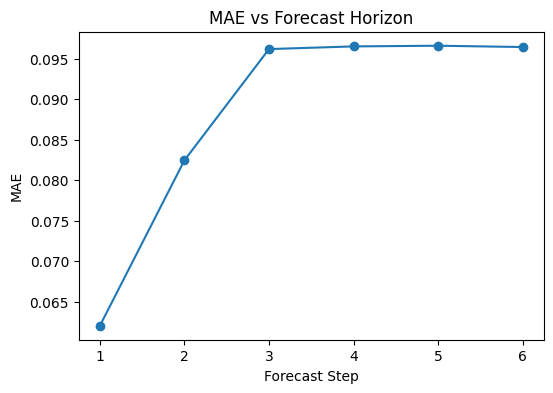

In [14]:
# MAE per Forecast Horizon Step
mae_per_step = np.mean(np.abs(y1_test - y1_pred), axis=(0,2))

plt.figure(figsize=(6,4))
plt.plot(range(1,7), mae_per_step, marker='o')
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Forecast Step")
plt.ylabel("MAE")
plt.show()


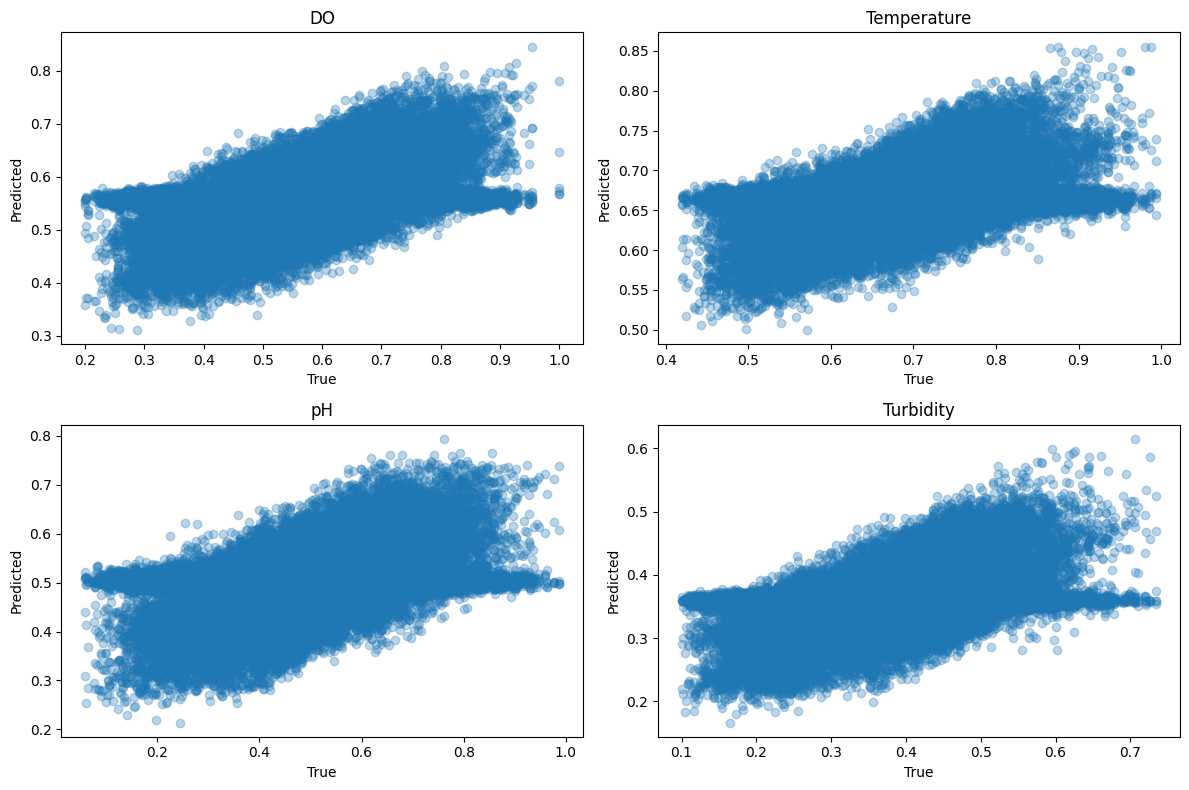

In [15]:
# Predicted vs True Scatter Plot
plt.figure(figsize=(12,8))

for i, param in enumerate(params):
    plt.subplot(2,2,i+1)
    plt.scatter(y1_test[:,:,i].flatten(), y1_pred[:,:,i].flatten(), alpha=0.3)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(param)

plt.tight_layout()
plt.show()


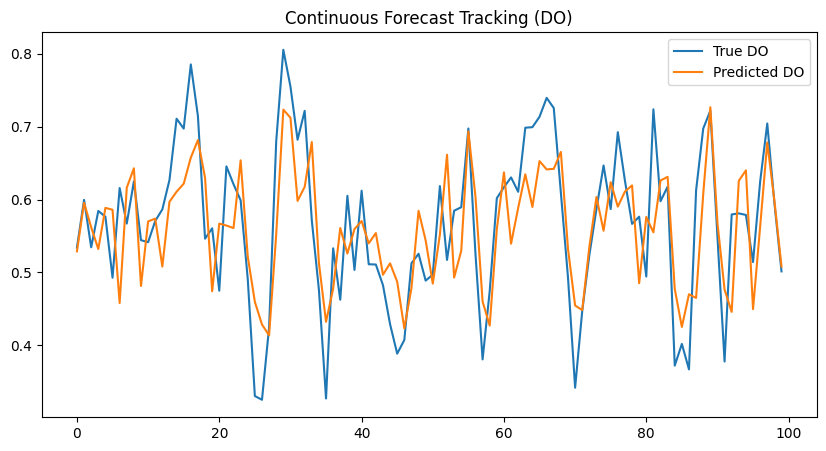

In [16]:
# Time-Series Overlay (Long Continuous Segment)
start = 1000
length = 100

true_segment = y1_test[start:start+length, 0, 0]   # DO at first future step
pred_segment = y1_pred[start:start+length, 0, 0]

plt.figure(figsize=(10,5))
plt.plot(true_segment, label="True DO")
plt.plot(pred_segment, label="Predicted DO")
plt.title("Continuous Forecast Tracking (DO)")
plt.legend()
plt.show()
